# ⚠️ DEPRECATED — Machine Learning

**This notebook has been superseded by `final_pipeline.ipynb (Steps 9–11)`.**

This file is retained for development history purposes only. 
For the final, reproducible analysis, please refer to **`final_pipeline.ipynb (Steps 9–11)`**.

---


Cookie Cats Machine Learning Pipeline

This script implements a machine learning pipeline to predict player retention
(churn vs retention) using the Cookie Cats dataset.

To use this as a Jupyter notebook:
1. Run: jupyter notebook in the notebooks directory
2. Create a new notebook and use %load 03_modeling.py
3. Run the cells

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_imb_pipeline
import os

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the dataset
try:
    data_path = os.path.join('..', 'data', 'cookie_cats.csv')
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Dataset not found. Please ensure the file 'cookie_cats.csv' is in the data/ directory.")

Dataset loaded successfully!
Shape: (90189, 5)


## 2. Data Preparation

In [3]:
# Create target variable (7-day retention)
df['target'] = df['retention_7'].astype(int)

# Define features and target
features = ['sum_gamerounds', 'version']
X = df[features]
y = df['target']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Class distribution in training: {y_train.mean():.4f}")

Training set size: 72151
Test set size: 18038
Class distribution in training: 0.1861


## 3. Pipeline Design

In [4]:
# Define preprocessing for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['sum_gamerounds']),
        ('cat', OneHotEncoder(), ['version'])
    ])

## 4. Model Training and Evaluation

In [5]:
# Define models to evaluate
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [6]:
# Train and evaluate each model
results = {}
for name, model in models.items():
    # Create pipeline
    pipeline = make_imb_pipeline(
        preprocessor,
        SMOTE(random_state=42),
        model
    )
    
    # Fit the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Store results
    results[name] = {
        'pipeline': pipeline,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    # Print classification report
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     14682
           1       0.59      0.70      0.64      3356

    accuracy                           0.85     18038
   macro avg       0.76      0.80      0.78     18038
weighted avg       0.87      0.85      0.86     18038

ROC AUC: 0.8871

Random Forest Results:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87     14682
           1       0.48      0.81      0.60      3356

    accuracy                           0.80     18038
   macro avg       0.71      0.80      0.73     18038
weighted avg       0.86      0.80      0.82     18038

ROC AUC: 0.8820

XGBoost Results:
              precision    recall  f1-score   support

           0       0.95      0.81      0.87     14682
           1       0.49      0.80      0.61      3356

    accuracy                           0.81     18038
   macro avg       0.72 

## 5. Model Comparison

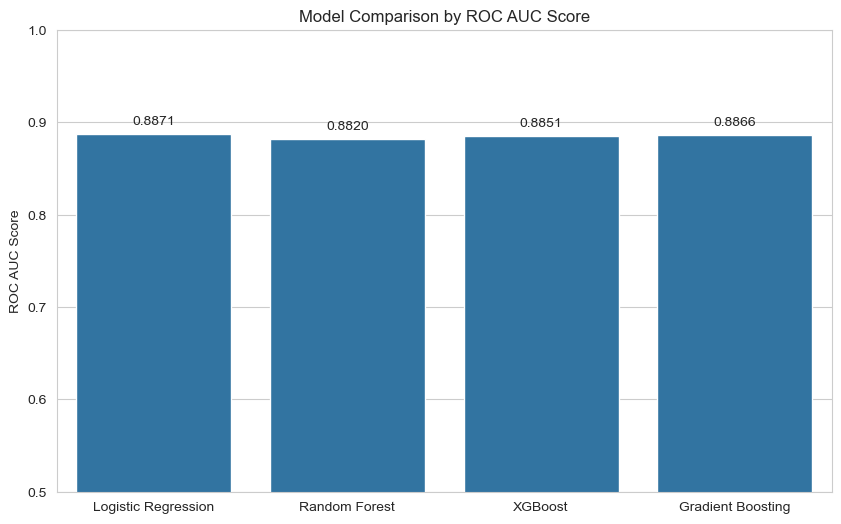

In [7]:
# Compare model performance
model_names = list(results.keys())
roc_auc_scores = [results[name]['roc_auc'] for name in model_names]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=roc_auc_scores)
plt.title('Model Comparison by ROC AUC Score')
plt.ylabel('ROC AUC Score')
plt.ylim(0.5, 1.0)
for i, score in enumerate(roc_auc_scores):
    plt.text(i, score + 0.01, f'{score:.4f}', ha='center')
plt.show()

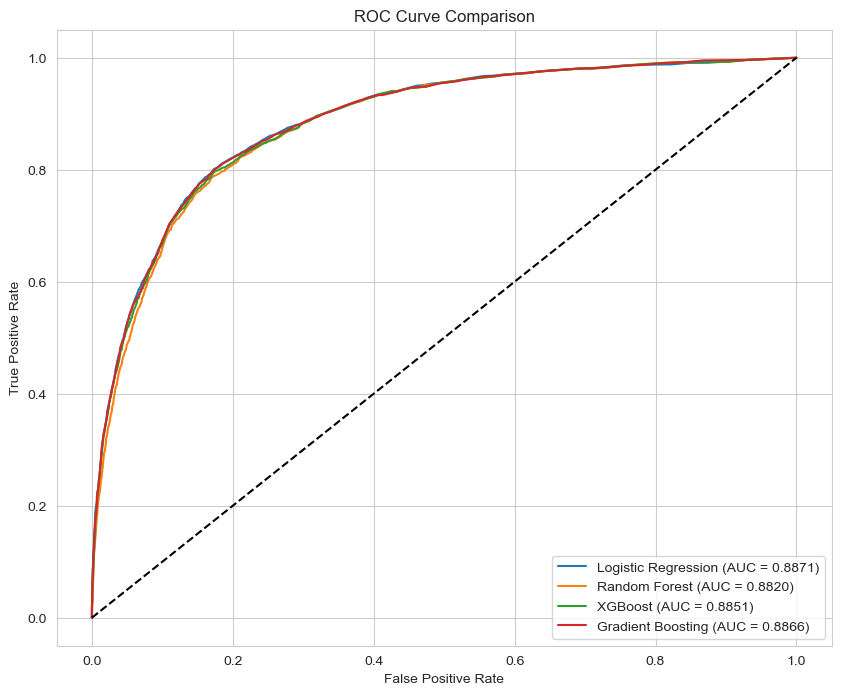

In [8]:
# Plot ROC curves
plt.figure(figsize=(10, 8))
for name in model_names:
    fpr, tpr, _ = roc_curve(y_test, results[name]['probabilities'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results[name]["roc_auc"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## 6. Feature Importance

In [9]:
# Get feature names after preprocessing
feature_names = ['sum_gamerounds']
if 'cat' in preprocessor.named_transformers_:
    cat_encoder = preprocessor.named_transformers_['cat']
    if hasattr(cat_encoder, 'get_feature_names_out'):
        cat_features = cat_encoder.get_feature_names_out(['version'])
        feature_names.extend(cat_features)

In [10]:
# Plot feature importance for the best model
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['pipeline']

if hasattr(best_model.named_steps[best_model_name.lower().replace(' ', '')], 'feature_importances_'):
    importances = best_model.named_steps[best_model_name.lower().replace(' ', '')].feature_importances_
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances, y=feature_names)
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xlabel('Importance Score')
    plt.show()

## 7. Hyperparameter Tuning

In [11]:
# Example: Hyperparameter tuning for XGBoost
if 'XGBoost' in results:
    param_grid = {
        'xgbclassifier__n_estimators': [50, 100, 200],
        'xgbclassifier__max_depth': [3, 5, 7],
        'xgbclassifier__learning_rate': [0.01, 0.1, 0.2]
    }
    
    grid_search = GridSearchCV(
        make_imb_pipeline(preprocessor, SMOTE(random_state=42), XGBClassifier(random_state=42)),
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")
    
    # Evaluate on test set
    y_pred_proba = grid_search.predict_proba(X_test)[:, 1]
    print(f"Test ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Best parameters: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 50}
Best CV score: 0.8887
Test ROC AUC: 0.8873


## 8. Next Steps

In [12]:
print("""Next steps:
1. Refactor the pipeline into modular Python scripts
2. Create comprehensive visualizations for reporting
3. Augment data with external industry benchmarks
4. Finalize the analysis and create a report""")

Next steps:
1. Refactor the pipeline into modular Python scripts
2. Create comprehensive visualizations for reporting
3. Augment data with external industry benchmarks
4. Finalize the analysis and create a report
